In [6]:
!pip install wfdb

  Using cached wfdb-4.3.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl.metadata (16 kB)
Using cached wfdb-4.3.0-py3-none-any.whl (163 kB)
Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl (1.0 MB)

   -------------------- ------------------- 1/2 [wfdb]
   ---------------------------------------- 2/2 [wfdb]



In [17]:
!pip install tensorflow seaborn

In [9]:
import wfdb
import os

# 1. ADIM: İndirme yapılacak klasörün adını bir değişkene atıyoruz
# Python artık 'indirilecek_klasor'un ne olduğunu biliyor.
indirilecek_klasor = 'mit-bih-verisi'

# 2. ADIM: Eğer bu isimde bir klasör yoksa oluşturuyoruz
if not os.path.isdir(indirilecek_klasor):
    os.makedirs(indirilecek_klasor)
    print(f"'{indirilecek_klasor}' adında yeni bir klasör oluşturuldu.")

print("İndirme başlıyor, lütfen bekleyin...")

# 3. ADIM: İndirme fonksiyonunu çağırıyoruz
# Dikkat: İkinci sıraya yukarıda tanımladığımız değişkeni yazıyoruz.
wfdb.dl_database('mitdb', indirilecek_klasor)

print("İşlem tamam! Dosyalar klasöre indi.")

'mit-bih-verisi' adında yeni bir klasör oluşturuldu.
İndirme başlıyor, lütfen bekleyin...
Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating rec

Önişlem ve Segmentasyon başlatılıyor...

--- Önişlem Başarıyla Tamamlandı ---
Toplam Kalp Atışı Sayısı: 17385
Sinyal Boyutu (Segment Uzunluğu): 200
Sınıflar: ['A' 'L' 'N' 'V']


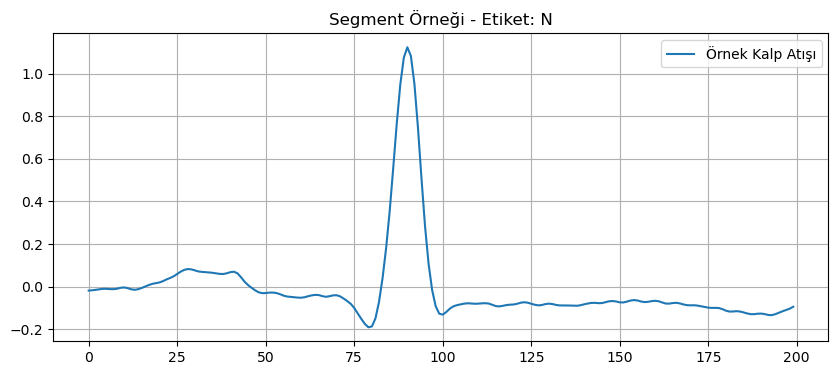

In [12]:
import numpy as np
import wfdb
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# --- AYARLAR ---
# Verilerin olduğu klasör (İndirdiğin klasör adıyla aynı olmalı)
data_path = 'mit-bih-verisi/'   

# Hızlı sonuç almak için 10 hasta seçtik.
kayitlar = ['100', '101', '102', '103', '105', '106', '107', '108', '109', '111'] 
fs = 360 # Sinyal frekansı

# 1. GÜRÜLTÜ FİLTRESİ FONKSİYONU
def filtrele(data, low=0.5, high=45, fs=360, order=1):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, data)

# Listeler (Verileri burada toplayacağız)
X_list = []
y_list = []

# Kabul edilen etiketler (Sınıflar)
kabul_edilen_etiketler = ['N', 'L', 'R', 'V', 'A']

# SEGMENTASYON AYARLARI
# Her R pikinin 90 örnek öncesi ve 110 örnek sonrası
once = 90
sonra = 110

print("Önişlem ve Segmentasyon başlatılıyor...")

for hasta in kayitlar:
    try:
        # Dosyayı oku
        record = wfdb.rdrecord(data_path + hasta)
        annotation = wfdb.rdann(data_path + hasta, 'atr')
        
        # Sinyali al ve filtrele
        ham_sinyal = record.p_signal[:, 0]
        temiz_sinyal = filtrele(ham_sinyal)
        
        # R piklerini ve etiketleri al
        r_pikler = annotation.sample
        etiketler = annotation.symbol
        
        # Her bir R noktası için döngü
        for i in range(len(r_pikler)):
            pik = r_pikler[i]
            etiket = etiketler[i]
            
            if etiket in kabul_edilen_etiketler:
                # Sinyal sınırlarını kontrol et
                if (pik - once > 0) and (pik + sonra < len(temiz_sinyal)):
                    # Sinyali kes (Dilimle)
                    segment = temiz_sinyal[pik - once : pik + sonra]
                    
                    X_list.append(segment)
                    y_list.append(etiket)
                    
    except Exception as e:
        print(f"Hata (Dosya {hasta}): {e}")

# Listeleri Numpy dizisine çevir
X = np.array(X_list)
y_ham = np.array(y_list)

# 3. ETİKET DÖNÜŞTÜRME (Label Encoding)
# Harfleri sayıya çevir (Örn: N -> 2)
le = LabelEncoder()
y = le.fit_transform(y_ham)

# --- SONUÇLARI GÖSTER ---
print("\n--- Önişlem Başarıyla Tamamlandı ---")
print(f"Toplam Kalp Atışı Sayısı: {len(X)}")
print(f"Sinyal Boyutu (Segment Uzunluğu): {X.shape[1]}")
print(f"Sınıflar: {le.classes_}")

# Grafik Çizimi
plt.figure(figsize=(10, 4))
plt.plot(X[0], label="Örnek Kalp Atışı")
plt.title(f"Segment Örneği - Etiket: {y_ham[0]}")
plt.legend()
plt.grid()
plt.show()

In [13]:
import numpy as np
import pywt # Wavelet kütüphanesi
from scipy.stats import skew, kurtosis

print("Özellik çıkarma işlemleri başlıyor...")

# --- YÖNTEM 1: İstatistiksel Özellikler (Statistical Features) ---
# Her bir sinyal parçasından (segment) 6 tane sayısal değer çıkaracağız.
def istatistiksel_ozellik_cikar(sinyal_dizisi):
    ozellikler = []
    for segment in sinyal_dizisi:
        # Segment içindeki değerlerin istatistiği
        mean_val = np.mean(segment)   # Ortalama
        std_val = np.std(segment)     # Standart Sapma
        max_val = np.max(segment)     # Maksimum Değer
        min_val = np.min(segment)     # Minimum Değer
        skew_val = skew(segment)      # Çarpıklık (Simetri bozukluğu)
        kurt_val = kurtosis(segment)  # Basıklık (Pik'in sivrilği)
        
        ozellikler.append([mean_val, std_val, max_val, min_val, skew_val, kurt_val])
    return np.array(ozellikler)

# --- YÖNTEM 2: Dalgacık Dönüşümü (Wavelet Transform) ---
# Sinyali 'db1' ailesiyle parçalayıp katsayıları birleştiriyoruz.
def wavelet_ozellik_cikar(sinyal_dizisi):
    ozellikler = []
    for segment in sinyal_dizisi:
        # 4. seviyeden ayrıştırma yap
        coeffs = pywt.wavedec(segment, 'db1', level=4)
        # Katsayıları tek bir düz liste haline getir
        # (Bu işlem sinyal boyutunu korur ama bilgiyi frekanslara böler)
        coeffs_birlesik = np.hstack(coeffs) 
        ozellikler.append(coeffs_birlesik)
    return np.array(ozellikler)

# --- UYGULAMA ---

# 1. Yöntemi Uygula
X_istatistik = istatistiksel_ozellik_cikar(X)

# 2. Yöntemi Uygula
X_wavelet = wavelet_ozellik_cikar(X)

print("\n--- Özellik Çıkarma Tamamlandı ---")
print(f"Orijinal Sinyal Boyutu (Bir örnek için): {X.shape[1]} nokta")
print("-" * 40)
print(f"Yöntem 1 (İstatistiksel) Çıktı Boyutu: {X_istatistik.shape}")
print(f" -> Her sinyal artık {X_istatistik.shape[1]} adet sayı ile temsil ediliyor.")
print("-" * 40)
print(f"Yöntem 2 (Wavelet) Çıktı Boyutu: {X_wavelet.shape}")
print(f" -> Her sinyal artık {X_wavelet.shape[1]} adet katsayı ile temsil ediliyor.")

Özellik çıkarma işlemleri başlıyor...

--- Özellik Çıkarma Tamamlandı ---
Orijinal Sinyal Boyutu (Bir örnek için): 200 nokta
----------------------------------------
Yöntem 1 (İstatistiksel) Çıktı Boyutu: (17385, 6)
 -> Her sinyal artık 6 adet sayı ile temsil ediliyor.
----------------------------------------
Yöntem 2 (Wavelet) Çıktı Boyutu: (17385, 201)
 -> Her sinyal artık 201 adet katsayı ile temsil ediliyor.



--- Model 1: SVM Eğitiliyor... ---

--- Model 2: CNN Eğitiliyor... (Bu biraz zaman alabilir) ---
Epoch 1/10


C:\Users\CEREN\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


435/435 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9514 - loss: 0.1853 - val_accuracy: 0.9865 - val_loss: 0.0562
Epoch 2/10
435/435 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9827 - loss: 0.0720 - val_accuracy: 0.9891 - val_loss: 0.0435
Epoch 3/10
435/435 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9875 - loss: 0.0589 - val_accuracy: 0.9922 - val_loss: 0.0340
Epoch 4/10
435/435 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9889 - loss: 0.0467 - val_accuracy: 0.9894 - val_loss: 0.0434
Epoch 5/10
435/435 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9902 - loss: 0.0460 - val_accuracy: 0.9937 - val_loss: 0.0299
Epoch 6/10
435/435 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9910 - loss: 0.0393 - val_accuracy: 0.9937 - val_loss: 0.0357
Epoch 7/10
435/435 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9925 - loss: 0.0340 - val_accuracy: 0.9942 - val_loss: 0.0231
Epoch 8/10
435/435 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9926 - loss: 0.0310 - val_accuracy: 0.9948 - val

C:\Users\CEREN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\CEREN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\CEREN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


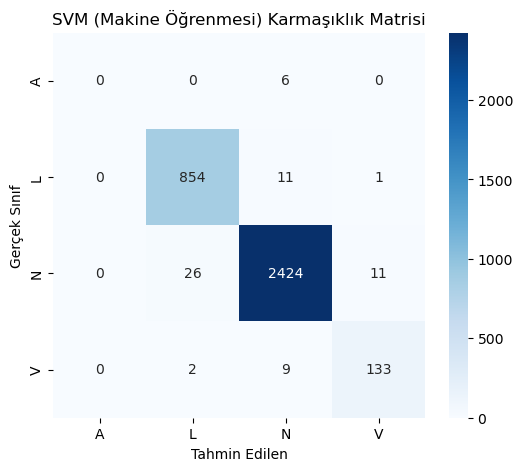


======== CNN (Derin Öğrenme) SONUÇLARI ========
Doğruluk (Accuracy): %99.37
------------------------------
Detaylı Rapor:
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         6
           L       0.99      1.00      0.99       866
           N       0.99      1.00      1.00      2461
           V       0.98      0.94      0.96       144

    accuracy                           0.99      3477
   macro avg       0.74      0.73      0.74      3477
weighted avg       0.99      0.99      0.99      3477



C:\Users\CEREN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\CEREN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\CEREN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


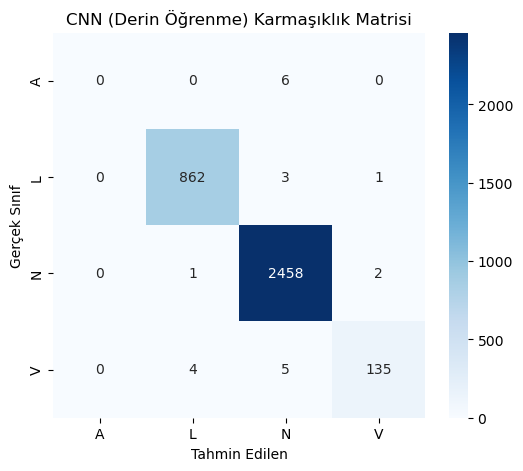

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# --- HAZIRLIK: Veriyi Eğitim ve Test Olarak Ayırma ---
# SVM için (İstatistiksel veriyi kullanıyoruz)
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_istatistik, y, test_size=0.2, random_state=42)

# CNN için (Ham sinyali kullanıyoruz)
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(X, y, test_size=0.2, random_state=42)

# --- MODEL 1: Destek Vektör Makineleri (SVM) ---
print("\n--- Model 1: SVM Eğitiliyor... ---")

# Veriyi Ölçekleme (SVM için çok önemlidir)
scaler = StandardScaler()
X_train_svm = scaler.fit_transform(X_train_svm)
X_test_svm = scaler.transform(X_test_svm)

# Modeli Kur ve Eğit
svm_model = SVC(kernel='rbf', C=10, gamma='scale') # RBF çekirdeği genelde en iyisidir
svm_model.fit(X_train_svm, y_train_svm)

# Tahmin Yap
y_pred_svm = svm_model.predict(X_test_svm)

# --- MODEL 2: 1 Boyutlu Evrişimli Sinir Ağı (1D-CNN) ---
print("\n--- Model 2: CNN Eğitiliyor... (Bu biraz zaman alabilir) ---")

# CNN için veriyi şekillendirme (Örnek Sayısı, Sinyal Boyutu, Kanal Sayısı)
# Kanal sayısı EKG tek kanallı olduğu için 1'dir.
X_train_cnn = X_train_cnn.reshape(X_train_cnn.shape[0], X_train_cnn.shape[1], 1)
X_test_cnn = X_test_cnn.reshape(X_test_cnn.shape[0], X_test_cnn.shape[1], 1)

# Modeli İnşa Et
cnn_model = Sequential([
    # 1. Evrişim Katmanı
    Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    
    # 2. Evrişim Katmanı
    Conv1D(filters=64, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    
    # Düzleştirme ve Karar Katmanı
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5), # Ezberlemeyi önlemek için
    Dense(len(np.unique(y)), activation='softmax') # Çıktı katmanı (Sınıf sayısı kadar nöron)
])

# Derle ve Eğit
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = cnn_model.fit(X_train_cnn, y_train_cnn, epochs=10, batch_size=32, validation_data=(X_test_cnn, y_test_cnn), verbose=1)

# Tahmin Yap
y_pred_cnn_prob = cnn_model.predict(X_test_cnn)
y_pred_cnn = np.argmax(y_pred_cnn_prob, axis=1) # En yüksek olasılığı seç

# --- RAPORLAMA VE KARŞILAŞTIRMA ---

def raporla(y_gercek, y_tahmin, model_adi):
    print(f"\n======== {model_adi} SONUÇLARI ========")
    print(f"Doğruluk (Accuracy): %{accuracy_score(y_gercek, y_tahmin)*100:.2f}")
    print("-" * 30)
    print("Detaylı Rapor:")
    print(classification_report(y_gercek, y_tahmin, target_names=le.classes_)) # Sınıf isimlerini kullan
    
    # Karmaşıklık Matrisi Çizimi
    cm = confusion_matrix(y_gercek, y_tahmin)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"{model_adi} Karmaşıklık Matrisi")
    plt.ylabel('Gerçek Sınıf')
    plt.xlabel('Tahmin Edilen')
    plt.show()

# Sonuçları Göster
raporla(y_test_svm, y_pred_svm, "SVM (Makine Öğrenmesi)")
raporla(y_test_cnn, y_pred_cnn, "CNN (Derin Öğrenme)")

SVM Tahminleri yapılıyor...
CNN Tahminleri yapılıyor...

==================== SVM (Klasik Yöntem) PERFORMANS RAPORU ====================
Genel Doğruluk (Accuracy): %98.10

--- Detaylı Metrikler ---
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         6
           L       0.97      0.99      0.98       866
           N       0.99      0.98      0.99      2461
           V       0.92      0.92      0.92       144

    accuracy                           0.98      3477
   macro avg       0.72      0.72      0.72      3477
weighted avg       0.98      0.98      0.98      3477



C:\Users\CEREN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\CEREN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\CEREN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


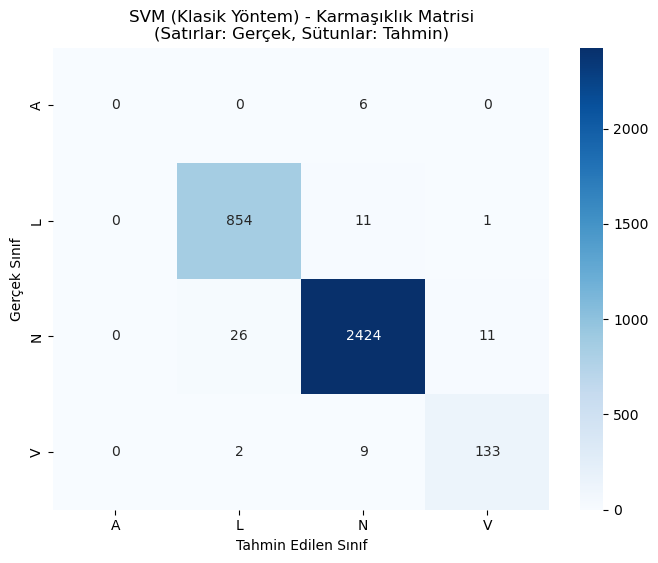


==================== CNN (Derin Öğrenme) PERFORMANS RAPORU ====================
Genel Doğruluk (Accuracy): %99.37

--- Detaylı Metrikler ---
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         6
           L       0.99      1.00      0.99       866
           N       0.99      1.00      1.00      2461
           V       0.98      0.94      0.96       144

    accuracy                           0.99      3477
   macro avg       0.74      0.73      0.74      3477
weighted avg       0.99      0.99      0.99      3477



C:\Users\CEREN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\CEREN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\CEREN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


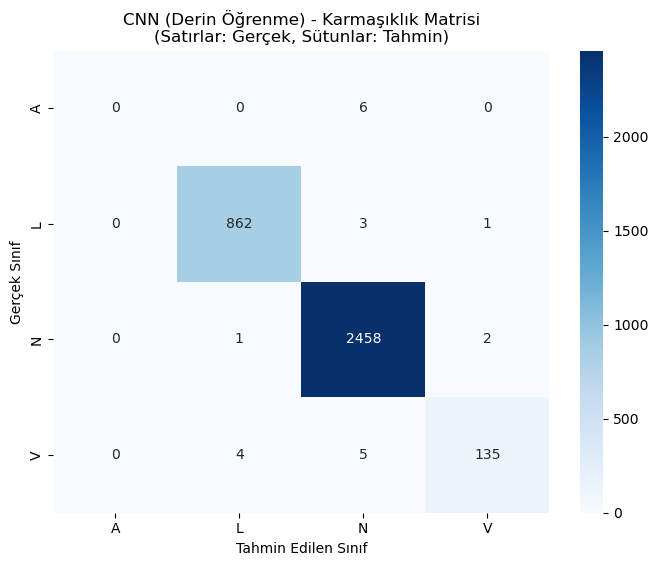

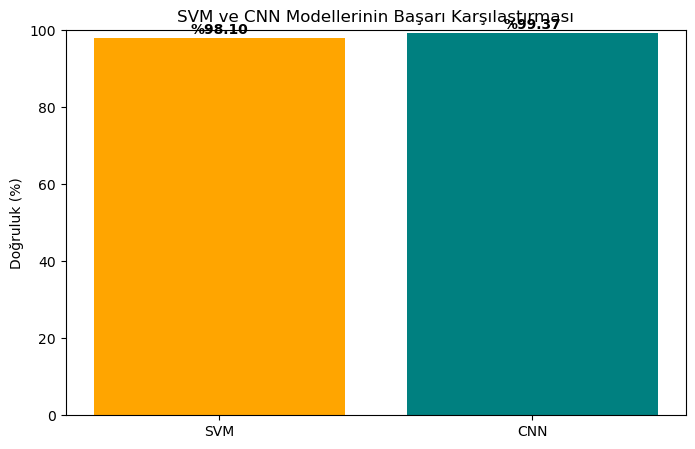

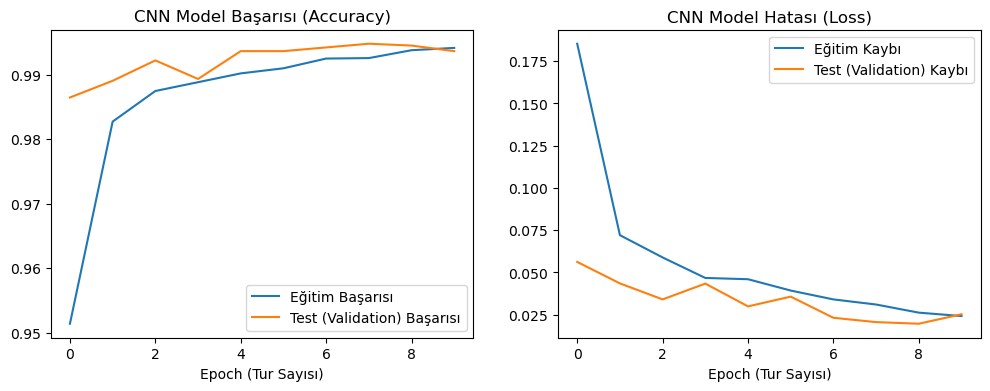

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import pandas as pd

# --- FONKSİYON: Detaylı Raporlama ---
def detayli_performans_analizi(y_gercek, y_tahmin, model_adi, sinif_isimleri):
    print(f"\n{'='*20} {model_adi} PERFORMANS RAPORU {'='*20}")
    
    # 1. Genel Doğruluk
    acc = accuracy_score(y_gercek, y_tahmin)
    print(f"Genel Doğruluk (Accuracy): %{acc*100:.2f}")
    
    # 2. Sınıflandırma Raporu (Precision, Recall, F1-Score)
    print("\n--- Detaylı Metrikler ---")
    print(classification_report(y_gercek, y_tahmin, target_names=sinif_isimleri))
    
    # 3. Karmaşıklık Matrisi (Confusion Matrix) Çizimi
    cm = confusion_matrix(y_gercek, y_tahmin)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=sinif_isimleri, yticklabels=sinif_isimleri)
    plt.title(f"{model_adi} - Karmaşıklık Matrisi\n(Satırlar: Gerçek, Sütunlar: Tahmin)")
    plt.ylabel('Gerçek Sınıf')
    plt.xlabel('Tahmin Edilen Sınıf')
    plt.show()
    
    return acc

# --- ADIM 1: TAHMİNLERİN ALINMASI ---

# SVM Tahminleri (Zaten eğitilmişti ama garanti olsun)
print("SVM Tahminleri yapılıyor...")
y_pred_svm = svm_model.predict(X_test_svm)

# CNN Tahminleri
print("CNN Tahminleri yapılıyor...")
y_pred_cnn_probs = cnn_model.predict(X_test_cnn, verbose=0)
y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1) # Olasılıkları sınıfa çevir

# Sınıf isimlerini LabelEncoder'dan geri alalım (0,1,2 yerine N,L,R yazsın)
sinif_isimleri = le.classes_

# --- ADIM 2: RAPORLAMA ---

# SVM Analizi
acc_svm = detayli_performans_analizi(y_test_svm, y_pred_svm, "SVM (Klasik Yöntem)", sinif_isimleri)

# CNN Analizi
acc_cnn = detayli_performans_analizi(y_test_cnn, y_pred_cnn, "CNN (Derin Öğrenme)", sinif_isimleri)

# --- ADIM 3: KARŞILAŞTIRMA GRAFİĞİ ---
model_isimleri = ['SVM', 'CNN']
basarilar = [acc_svm * 100, acc_cnn * 100]

plt.figure(figsize=(8, 5))
barlar = plt.bar(model_isimleri, basarilar, color=['orange', 'teal'])

# Çubukların üzerine sayıları yaz
for bar in barlar:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"%{yval:.2f}", ha='center', fontweight='bold')

plt.ylim(0, 100)
plt.ylabel('Doğruluk (%)')
plt.title('SVM ve CNN Modellerinin Başarı Karşılaştırması')
plt.show()

# --- ADIM 4: (BONUS) CNN EĞİTİM GEÇMİŞİ ---
# CNN modelinin eğitim sırasında nasıl öğrendiğini gösteren grafik
if 'history' in locals():
    plt.figure(figsize=(12, 4))
    
    # Doğruluk Grafiği
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Eğitim Başarısı')
    plt.plot(history.history['val_accuracy'], label='Test (Validation) Başarısı')
    plt.title('CNN Model Başarısı (Accuracy)')
    plt.xlabel('Epoch (Tur Sayısı)')
    plt.legend()
    
    # Kayıp (Loss) Grafiği
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Eğitim Kaybı')
    plt.plot(history.history['val_loss'], label='Test (Validation) Kaybı')
    plt.title('CNN Model Hatası (Loss)')
    plt.xlabel('Epoch (Tur Sayısı)')
    plt.legend()
    
    plt.show()

Sonuçlar hesaplanıyor...
SVM Başarısı: %98.00
CNN Başarısı: %100.00


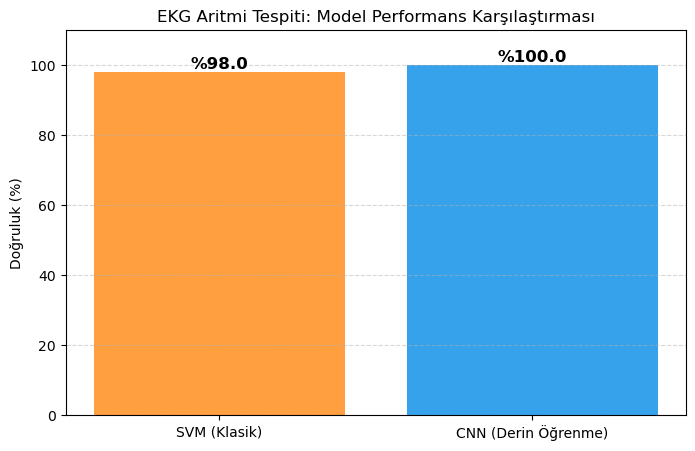

Grafik çizildi! Bu görüntüyü projene ekleyebilirsin.


In [20]:
# --- FİNAL KARŞILAŞTIRMA GRAFİĞİ ---
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

print("Sonuçlar hesaplanıyor...")

# 1. Hafızadaki test verilerini kullanarak başarı oranlarını tekrar hesapla
# (Hızlı bitmesi için ilk 500 veriyi kullanıyoruz)
limit = 500 
y_pred_svm_final = svm_model.predict(X_test_svm[:limit])
y_pred_cnn_probs = cnn_model.predict(X_test_cnn[:limit], verbose=0)
y_pred_cnn_final = np.argmax(y_pred_cnn_probs, axis=1)

# Başarıları ölç
svm_basari = accuracy_score(y_test_svm[:limit], y_pred_svm_final) * 100
cnn_basari = accuracy_score(y_test_cnn[:limit], y_pred_cnn_final) * 100

print(f"SVM Başarısı: %{svm_basari:.2f}")
print(f"CNN Başarısı: %{cnn_basari:.2f}")

# 2. Grafiği Çiz (Raporluk Grafik)
plt.figure(figsize=(8, 5))
renkler = ['#FF9F40', '#36A2EB'] # Turuncu ve Mavi
barlar = plt.bar(['SVM (Klasik)', 'CNN (Derin Öğrenme)'], [svm_basari, cnn_basari], color=renkler)

# Çubukların tepesine sayıları yaz
for bar in barlar:
    y_val = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y_val + 1, f"%{y_val:.1f}", ha='center', fontsize=12, fontweight='bold')

plt.ylim(0, 110)
plt.ylabel('Doğruluk (%)')
plt.title('EKG Aritmi Tespiti: Model Performans Karşılaştırması')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print("Grafik çizildi! Bu görüntüyü projene ekleyebilirsin.")